<center><span style="font-size:50px;"><b>ANALYSIS OF CUTS ON MC</b></span></center>

In this notebook we want to search for the best cuts of the Monte Carlo data, in order to try them later in real data.  
Here we only look for the raw MC data, so the single tracks, NOT the ones obtained after the pairs search (combinatory).

The codes in the pdg are:

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from collections import Counter

import gc
import itertools
import os
import glob

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

---

---

---

<center><span style="font-size:35px;"><b>ACCESSING DATA</b></span></center>

In [2]:
path = "/home/benedetto/Scrivania/LCP_B/project/MC_raw_data_from_VM/001_010/AO2Dtree.root"

# debug:
file = uproot.open(path)
diction = file.classnames()
for k, v in list(diction.items())[:7]:
    print(k, v)

DF_2303121152302944;1 TDirectory
DF_2303121152302944/O2mccollision;1 TTree
DF_2303121152302944/O2collision_001;1 TTree
DF_2303121152302944/O2filtertrack;1 TTree
DF_2303121152302944/O2filtertrackextr;1 TTree
DF_2303121152302944/O2filtertrackmc;1 TTree
DF_2303121152302944/O2genparticles;1 TTree


In [3]:
# # debug
# file["DF_2303121152302944/O2filtertrackextr"].show()

In [4]:
# # debug
# df_test = file["DF_2303121152302944/O2filtertrackmc"].arrays(library="pd")
# df_test["fMainHfMotherPdgCode"].value_counts()

In [5]:
# debug
df_test = file["DF_2303121152302944/O2filtertrackextr"].arrays(library="pd")
df_test.tail(5)

,fPt,fEta,fCharge,fDcaXY,fDcaZ,fSigmaDcaXY2,fSigmaDcaZ2,fNsigmaTPCpi,fNsigmaTPCka,fNsigmaTPCpr,fNsigmaTOFpi,fNsigmaTOFka,fNsigmaTOFpr
6186,0.520507,-0.750949,1,-0.004341,0.008275,0.000023,0.000035,0.294119,-3.098816,-9.621442,-999.000000,-999.000000,-999.000000
6187,0.657543,0.736443,1,0.002267,-0.003376,0.000025,0.000038,-0.641760,-2.451280,-8.418551,1.816856,-23.598524,-47.244957
6188,1.409657,-0.771347,-1,0.002688,0.002468,0.000007,0.000011,-1.136653,0.636019,-0.777613,0.441942,-7.789932,-19.709839
6189,0.347745,0.792705,-1,0.003879,0.005754,0.000059,0.000097,0.933263,-8.413826,-18.812960,-999.000000,-999.000000,-999.000000
6190,0.459839,0.639778,-1,-0.004815,0.000018,0.000034,0.000049,0.272564,-4.951161,-11.705180,-0.266166,-36.795307,-71.208565


In [6]:
# debug
names_dirs = file.keys(filter_classname="TDirectory")
print(f"We have --{len(names_dirs)}-- directories of data in this chunk.")

We have --314-- directories of data in this chunk.


<center><span style="font-size:35px;"><b>UPLOADING DATA</b></span></center>

In [7]:
# UPLOAD PATH:
base_path = "/home/benedetto/Scrivania/LCP_B/project/MC_raw_data_from_VM"
chunk_list = ["001_010", "011_020", "021_030", "031_040"]
file_name = "AO2Dtree.root"

# initialization:
list_for_gloabl_dataframe = []

for i_chunk in chunk_list:

    # PATH:
    path = f"{base_path}/{i_chunk}/{file_name}"
    file = uproot.open(path)
    
    # UPLOAD INITIALIZATION
    names_track_extr = file.keys(filter_name=r"*O2filtertrackextr")
    names_track      = file.keys(filter_name=r"*O2filtertrack")
    names_coll       = file.keys(filter_name=r"*O2collision_001")
    
    names_mc_gen     = file.keys(filter_name=r"*O2genparticles")
    names_mc_track   = file.keys(filter_name=r"*O2filtertrackmc")
    names_mc_coll    = file.keys(filter_name=r"*O2mccollision")
    
    num = len(names_coll)             # number of directories to unify (like DF_2303121152302944, etc)
    
    list_of_df = []                   # add the dataframes in a list (we will concat them later)
    
    collision_offset =  np.int64(0)   # variable to correct the index of the collision (because it starts from 0 at each new TTree)
    collision_offset_mc = np.int64(0)
    
    for i in range(num):          # cycle over directories (each with 6 TTrees)
    
        # READING DIRECTORIES:
        df_coll = file[ names_coll[i] ].arrays(["fPosZ"], library="pd")
        df_trackextr = file[ names_track_extr[i] ].arrays(["fPt", "fEta", "fCharge", "fDcaXY",
             "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTOFpi", "fNsigmaTOFka"], library="pd" )
        df_track = file[ names_track[i] ].arrays(["fIndexCollisions", "fAlpha", "fX", "fY", "fZ"], library="pd")
        # take the corresponding data of MC and merge it in df_track
        df_track_mc = file[names_mc_track[i]].arrays(["fPdgCode","fMainMotherOrigIndex","fMainHfMotherPdgCode","fMainMotherNfinalStateDaught",
                                                      "fMainBeautyAncestorPdgCode"],library="pd")
        df_track = pd.merge(left=df_track, 
                             right=df_track_mc, 
                             how='inner', left_index=True, right_index=True)   # I simply create a new dataframe given by those two side by side
        # merge track and trackextr:
        df_trackextr = pd.merge(left=df_trackextr, right=df_track, how='inner', left_index=True, right_index=True)
    
        
        # CUTS_________________________________________________________________________________________________________
        # we cut rows where the fIndexCollision is (for some unknown reason) negative 
        valid = df_trackextr["fIndexCollisions"] >= 0
        df_trackextr = df_trackextr[valid].reset_index(drop=True)  
    
    
        # MERGING COLLISION VARIABLES THROUGH INDEX COLLISION______________________________________________________________
        # Now we add fPosX,Y,Z as new columns (connecting them through fIndexCollisions) and cut over fPosZ
        df_trackextr["fPosZ"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosZ"].values
        df_trackextr = df_trackextr[(df_trackextr["fPosZ"] < 10) & (df_trackextr["fPosZ"] > -10)].reset_index(drop=True)
    
        # REINDEXING:
        new_indexes_main_mother, _ = pd.factorize(df_trackextr["fMainMotherOrigIndex"], sort=False)
        df_trackextr["fMainMotherOrigIndex"] = new_indexes_main_mother
        new_indexes_collision, _ = pd.factorize(df_trackextr["fIndexCollisions"], sort=False)
        df_trackextr["fIndexCollisions"] = new_indexes_collision
        # UPDATE indexes:
        max_coll_current = df_trackextr["fIndexCollisions"].max()  # raw max
        max_mc_current   = df_trackextr["fMainMotherOrigIndex"].max()  # raw max
        df_trackextr["fIndexCollisions"] += collision_offset
        df_trackextr["fMainMotherOrigIndex"] += collision_offset_mc 
    
        # KEPT VARIABLES ________________________________________________________________________________________________
        # We keep the variables over which we did the cut to see how they behave for the signal
        df_trackextr = df_trackextr[
                        ["fIndexCollisions", "fPdgCode", "fMainHfMotherPdgCode", "fPt", "fCharge", "fDcaXY",
                          "fNsigmaTPCpi", "fNsigmaTPCka","fNsigmaTOFpi", "fNsigmaTOFka",
                          "fMainMotherOrigIndex", "fMainMotherNfinalStateDaught", "fMainBeautyAncestorPdgCode"] ]
    
        list_of_df.append( df_trackextr )              # add the final dataframe in a list (we will concat them later)
        
        # UPDATE OFFSET for next loop:
        collision_offset += max_coll_current + 1
        collision_offset_mc += max_mc_current + 1
    
        # CLEANING SPACE
        del df_track
        del df_trackextr
        del df_coll
        del df_track_mc
    
        # END OF UPLOADING DATA FROM A PART OF A CHUNK_______________________________________________________________________________

    # MERGE all the dataframes/directories (of a part of a chunk) in a single dataframe
    df = pd.concat(list_of_df, ignore_index=True)
    N = len(df)
    del list_of_df
    list_for_gloabl_dataframe.append( df )              # add the final dataframe in a list (we will concat them later)

# MERGE all the dataframes/directories (of a part of a chunk) in a single dataframe
df = pd.concat(list_for_gloabl_dataframe, ignore_index=True)
N = len(df)
del list_for_gloabl_dataframe

In [8]:
# Debug
print(f"The uploaded dataframe has {len(df):_} rows and {len(df.columns)} columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"    It occupies {memory:.2f} MB")

display( pd.concat([df.head(5),df.tail(5)]) )

The uploaded dataframe has 8_877_719 rows and 13 columns.
    It occupies 507.99 MB


,fIndexCollisions,fPdgCode,fMainHfMotherPdgCode,fPt,fCharge,fDcaXY,fNsigmaTPCpi,fNsigmaTPCka,fNsigmaTOFpi,fNsigmaTOFka,fMainMotherOrigIndex,fMainMotherNfinalStateDaught,fMainBeautyAncestorPdgCode
0,0,211,0,1.328234,1,-0.008024,0.745507,1.912507,-1.992263,-11.110423,0,0,0
1,0,-211,0,0.818927,-1,-0.005362,0.089017,-1.574181,-1.437327,-21.357477,0,0,0
2,0,-211,0,1.151065,-1,-0.002529,-1.139159,-0.402068,-4.189509,-15.181988,0,0,0
3,0,211,0,0.596729,1,0.004228,-0.565151,-3.396817,-0.624115,-27.616001,0,0,0
4,0,211,0,0.704289,1,0.008957,0.544025,-2.476945,1918.979858,204.167679,0,0,0
8877714,179797,321,0,0.542256,1,-0.101200,4.806453,-0.686590,-999.000000,-999.000000,60029,0,0
8877715,179797,2212,0,0.652135,1,-0.052913,17.760324,12.176058,-999.000000,-999.000000,60029,0,0
8877716,179797,-211,0,0.346099,-1,-0.055054,1.252290,-8.361900,-999.000000,-999.000000,60029,0,0
8877717,179797,-211,0,1.695436,-1,-0.057284,0.662967,3.369998,-999.000000,-999.000000,60029,0,0
8877718,179797,-211,0,0.386838,-1,0.030822,0.154869,-7.404598,-999.000000,-999.000000,60029,0,0


In [9]:
# df.to_pickle("/home/benedetto/Scrivania/LCP_B/project/MC_raw_data_from_VM/raw_tracks_dataframe.pkl")

In [2]:
df = pd.read_pickle("/home/benedetto/Scrivania/LCP_B/project/MC_raw_data_from_VM/raw_tracks_dataframe.pkl")

---

---

## MASK FOR SIGNAL AND BACKGROUND

In [3]:
# DEFINING MASKS (candidate level)
# we use the term 'candidate' cause we also need to check the "fMainMotherOrigIndex" variable (we'll do it later)
candidate_mask_true_k_from_d0 = (
    (df["fPdgCode"] == -321 ) &
    (df["fMainHfMotherPdgCode"] == 421) &
    (df["fMainBeautyAncestorPdgCode"] == 0) &
    (df["fMainMotherNfinalStateDaught"] == 2)
)
candidate_mask_true_k_from_anti_d0 = (
    (df["fPdgCode"] == +321 ) &
    (df["fMainHfMotherPdgCode"] == -421) &
    (df["fMainBeautyAncestorPdgCode"] == 0) &
    (df["fMainMotherNfinalStateDaught"] == 2)
)
candidate_mask_true_pi_from_d0 = (
    (df["fPdgCode"] == +211 ) &
    (df["fMainHfMotherPdgCode"] == 421) &
    (df["fMainBeautyAncestorPdgCode"] == 0) &
    (df["fMainMotherNfinalStateDaught"] == 2)
)
candidate_mask_true_pi_from_anti_d0 = (
    (df["fPdgCode"] == -211 ) &
    (df["fMainHfMotherPdgCode"] == -421) &
    (df["fMainBeautyAncestorPdgCode"] == 0) &
    (df["fMainMotherNfinalStateDaught"] == 2)
)

# ------------------------------------------------------------------
# FIX FOR DUPLICATES: keep ONLY mothers with exactly 1 K and 1 π
# ------------------------------------------------------------------

# D0
kaon_counts_d0 = df[candidate_mask_true_k_from_d0].groupby("fMainMotherOrigIndex").size()
pion_counts_d0 = df[candidate_mask_true_pi_from_d0].groupby("fMainMotherOrigIndex").size()

good_d0_indexes = set(kaon_counts_d0[kaon_counts_d0 == 1].index).intersection( set(pion_counts_d0[pion_counts_d0 == 1].index) )

# anti-D0
kaon_counts_ad0 = df[candidate_mask_true_k_from_anti_d0].groupby("fMainMotherOrigIndex").size()
pion_counts_ad0 = df[candidate_mask_true_pi_from_anti_d0].groupby("fMainMotherOrigIndex").size()

good_anti_d0_indexes = set(kaon_counts_ad0[kaon_counts_ad0 == 1].index).intersection( set(pion_counts_ad0[pion_counts_ad0 == 1].index) )

# ------------------------------------------------------------------
# FINAL MASKS (using only the "good" mothers)
# ------------------------------------------------------------------

mask_true_k_from_d0 = (       candidate_mask_true_k_from_d0 & df["fMainMotherOrigIndex"].isin(good_d0_indexes) )
mask_true_pi_from_d0 = (      candidate_mask_true_pi_from_d0 & df["fMainMotherOrigIndex"].isin(good_d0_indexes) )
mask_true_k_from_anti_d0 = (  candidate_mask_true_k_from_anti_d0 &  df["fMainMotherOrigIndex"].isin(good_anti_d0_indexes) )
mask_true_pi_from_anti_d0 = ( candidate_mask_true_pi_from_anti_d0 & df["fMainMotherOrigIndex"].isin(good_anti_d0_indexes) )

mask_signal = ( mask_true_k_from_d0 | mask_true_pi_from_d0 | mask_true_k_from_anti_d0 | mask_true_pi_from_anti_d0 )
mask_background = ~mask_signal
mask_true_k = ( mask_true_k_from_d0 | mask_true_k_from_anti_d0 )
mask_true_pi = ( mask_true_pi_from_d0 | mask_true_pi_from_anti_d0 )
mask_true_d0 = ( mask_true_k_from_d0 | mask_true_pi_from_d0 )
mask_true_anti_d0 = ( mask_true_k_from_anti_d0 | mask_true_pi_from_anti_d0 )

# ------------------------------------------------------------------
# ADD TRUTH LABEL AND DROP EXTRA COLUMNS
# ------------------------------------------------------------------
df["truth"] = np.select( [mask_true_d0, mask_true_anti_d0], [1, -1], default=0 )

summarized_cols = [
    "fPdgCode",
    "fMainHfMotherPdgCode",
    "fMainBeautyAncestorPdgCode",
    "fMainMotherNfinalStateDaught",
    "fMainMotherOrigIndex"
]
df = df.drop(columns=summarized_cols)

WATCH OUT: There are D0 with more than two daughters particles (so like more pions or kaons with the same fMainMotherOrigIndex) even if they all have fMainMotherNfinalStateDaught==2!
```
# Example of debug output:
tmp = df[mask_true_k_from_d0 | mask_true_pi_from_d0]
counts = tmp.groupby("fMainMotherOrigIndex")["fPdgCode"].count()
print(counts.value_counts())

# output:
fPdgCode
2    6522
3    1277
4     226
5      27
6       5
Name: count, dtype: int64
```
We solved the problem by choosing as 'true' D0 only the ones with a single couple of Pi and Kaon.  
But another choice could be keeping them all and modify the way to count them.

In [4]:
# Debug
print(f"The uploaded dataframe has {len(df):_} rows and {len(df.columns)} columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"    It occupies {memory:.2f} MB")

display( pd.concat([df.head(5),df.tail(5)]) )

The uploaded dataframe has 8_877_719 rows and 9 columns.
    It occupies 372.52 MB


,fIndexCollisions,fPt,fCharge,fDcaXY,fNsigmaTPCpi,fNsigmaTPCka,fNsigmaTOFpi,fNsigmaTOFka,truth
0,0,1.328234,1,-0.008024,0.745507,1.912507,-1.992263,-11.110423,0
1,0,0.818927,-1,-0.005362,0.089017,-1.574181,-1.437327,-21.357477,0
2,0,1.151065,-1,-0.002529,-1.139159,-0.402068,-4.189509,-15.181988,0
3,0,0.596729,1,0.004228,-0.565151,-3.396817,-0.624115,-27.616001,0
4,0,0.704289,1,0.008957,0.544025,-2.476945,1918.979858,204.167679,0
8877714,179797,0.542256,1,-0.101200,4.806453,-0.686590,-999.000000,-999.000000,0
8877715,179797,0.652135,1,-0.052913,17.760324,12.176058,-999.000000,-999.000000,0
8877716,179797,0.346099,-1,-0.055054,1.252290,-8.361900,-999.000000,-999.000000,0
8877717,179797,1.695436,-1,-0.057284,0.662967,3.369998,-999.000000,-999.000000,0
8877718,179797,0.386838,-1,0.030822,0.154869,-7.404598,-999.000000,-999.000000,0


In [5]:
print(df.columns)

Index(['fIndexCollisions', 'fPt', 'fCharge', 'fDcaXY', 'fNsigmaTPCpi',
       'fNsigmaTPCka', 'fNsigmaTOFpi', 'fNsigmaTOFka', 'truth'],
      dtype='object')


In [6]:
# simple renaiming
final_results = df

In [13]:
# d0_tot = np.sum( mask_true_d0 )
# anti_d0_tot = np.sum( mask_true_anti_d0 )
# signal_tot = d0_tot + anti_d0_tot
# num_bg_pairs = np.sum( mask_background )
# print("Number of D0:      ", d0_tot )
# print("Number of anti-D0: ", anti_d0_tot )
# print(f"Number of background pairs: {num_bg_pairs:_}")
# print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

In [20]:
d0_tot = mask_true_d0.sum()/2
anti_d0_tot = mask_true_anti_d0.sum()/2
signal_total = d0_tot + anti_d0_tot
print(f"We have {mask_true_d0.sum()} tracks coming from D0 decays, i.e. {d0_tot:.0f} D0 mesons.")
print(f"We have {mask_true_anti_d0.sum()} tracks coming from anti-D0 decays, i.e. {anti_d0_tot:.0f} anti-D0 mesons.")
print(f"SO we have a total of {signal_total:.0f} of signal mother particles (D0 and anti-D0).\n")

print(f"We have {mask_true_k.sum()} true kaon ($K$±) tracks from D0 or anti-D0 decays.")
print(f"We have {mask_true_pi.sum()} true pion ($\pi$±) tracks from D0 or anti-D0 decays.\n")

print(f"We have {mask_signal.sum()} total signal tracks.")
print(f"We have {mask_background.sum():_} total background tracks.")

We have 13044 tracks coming from D0 decays, i.e. 6522 D0 mesons.
We have 13558 tracks coming from anti-D0 decays, i.e. 6779 anti-D0 mesons.
SO we have a total of 13301 of signal mother particles (D0 and anti-D0).

We have 13301 true kaon ($K$±) tracks from D0 or anti-D0 decays.
We have 13301 true pion ($\pi$±) tracks from D0 or anti-D0 decays.

We have 26602 total signal tracks.
We have 8_851_117 total background tracks.


---

---

---

<center><span style="font-size:35px;"><b>TRACK VARIABLES DISTRIBUTION</b></span></center>

Let's study the distribution of the variables for the known correct tracks. In this way we can do better cuts.

### $p_T$ OF SINGLE TRACKS

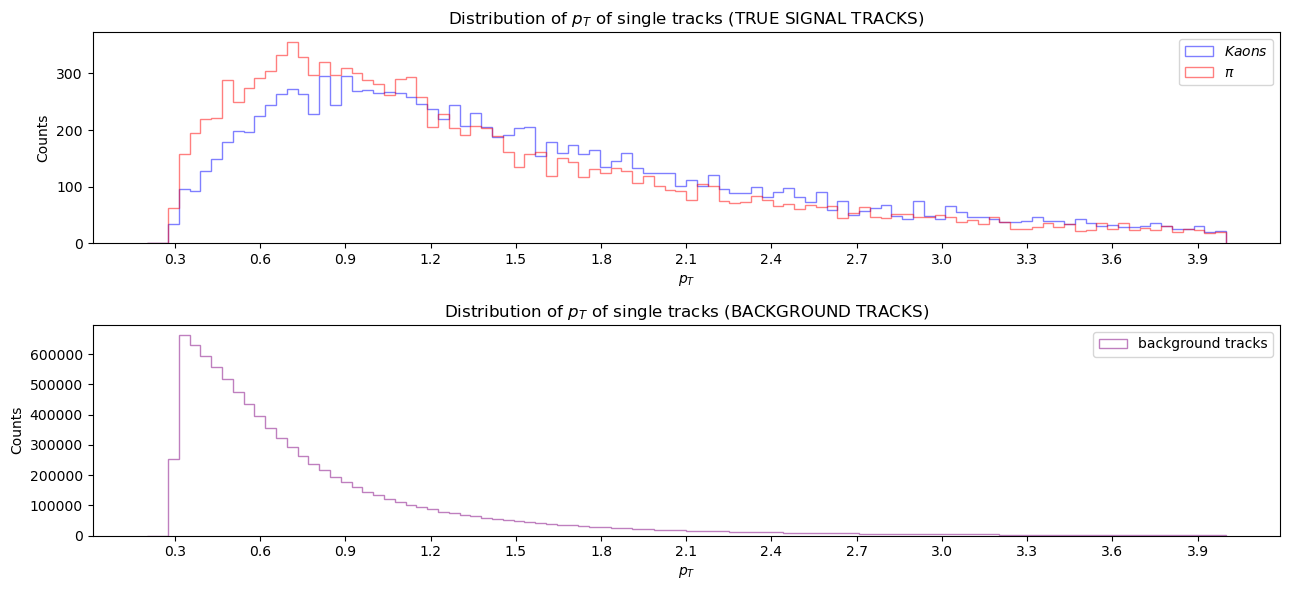

In [8]:
N_BINS = 100
range_min = 0.2
range_max = 4

num_of_plots = 2
fig, axs = plt.subplots( num_of_plots, 1, figsize=(13,3*num_of_plots)  )

# TRUE SIGNAL ---------------------------------------- 
data = final_results.loc[ mask_true_k, "fPt" ]
axs[0].hist( data , bins=N_BINS, range=(range_min, range_max), color="blue", alpha=0.5, label=r"$Kaons$", histtype='step')
data = final_results.loc[ mask_true_pi, "fPt" ]
axs[0].hist( data , bins=N_BINS, range=(range_min, range_max), color="red",  alpha=0.5, label=r"$\pi$", histtype='step')
axs[0].set_xlabel(r"$p_T$")
axs[0].set_ylabel("Counts")
axs[0].set_title(r"Distribution of $p_T$ of single tracks (TRUE SIGNAL TRACKS)")
axs[0].set_xticks(np.arange(0.3, range_max, 0.3))
axs[0].legend()

# BACKGROUND ---------------------------------------- 
data = final_results.loc[ mask_background, "fPt" ]
axs[1].hist( data , bins=N_BINS, range=(range_min, range_max), color="purple", alpha=0.5, label="background tracks", histtype='step')
axs[1].set_xlabel(r"$p_T$")
axs[1].set_ylabel("Counts")
axs[1].set_title(r"Distribution of $p_T$ of single tracks (BACKGROUND TRACKS)")
axs[1].set_xticks(np.arange(0.3, range_max, 0.3))
axs[1].legend()

plt.tight_layout()
plt.show()

del data

### $\pi^+$ TRACKS
Let's observe the distribution of the variables for the $\pi^+$ tracks, for both the known $D_0$ and also for all the combinatory background.

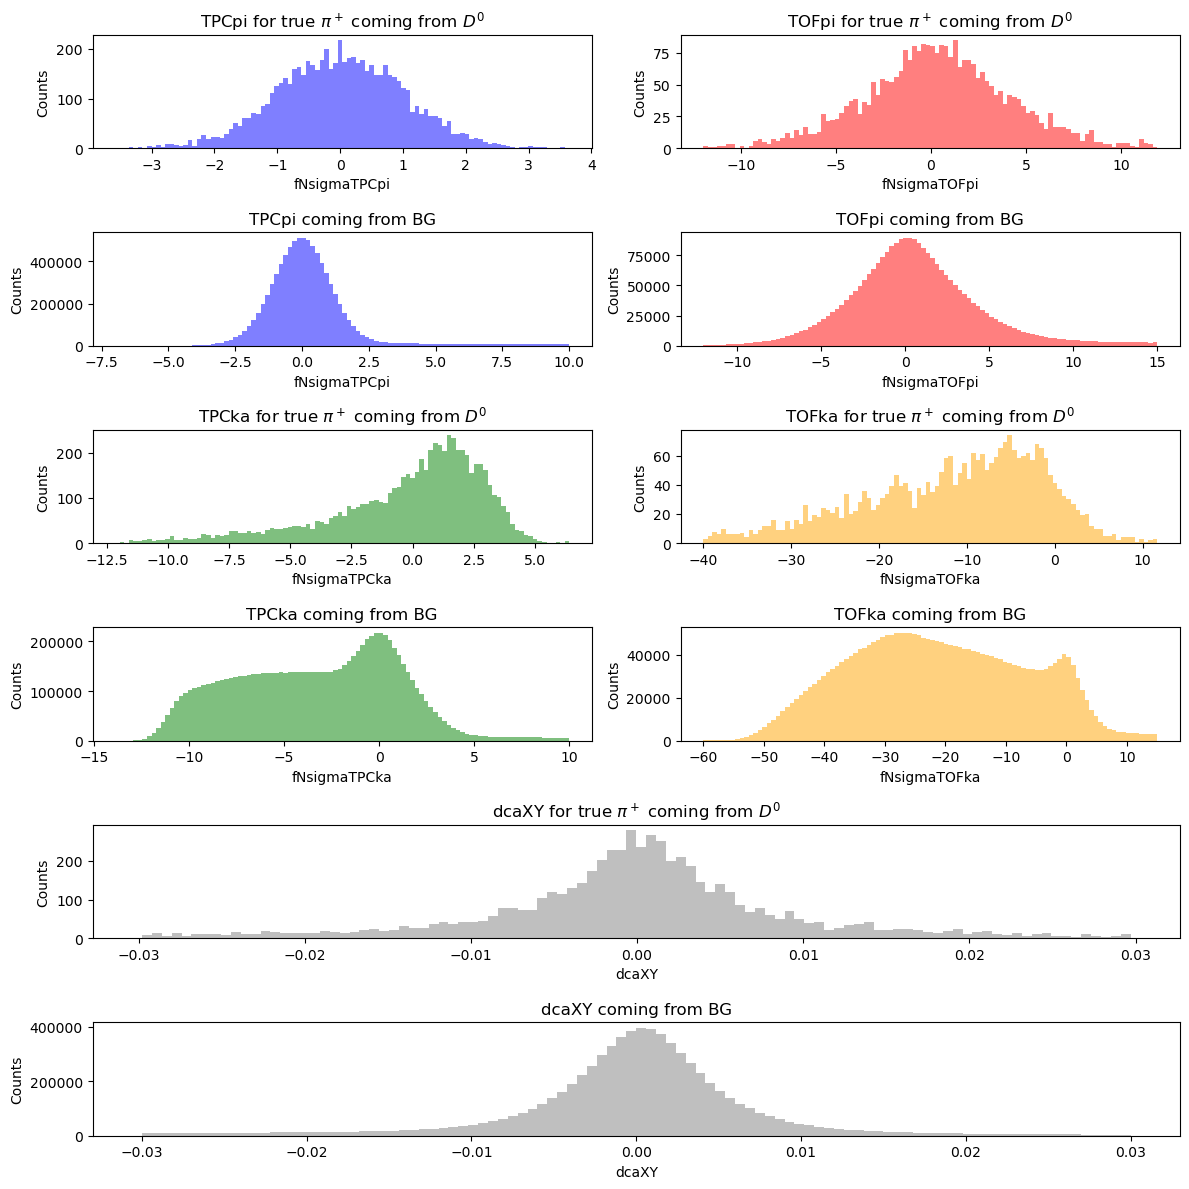

In [9]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi_D0", "tofpi_D0"],
    ["tpcpi_all", "tofpi_all"],
    ["tpcka_D0", "tofka_D0"],
    ["tpcka_all", "tofka_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 12)
)

# --- Plot TPCpi for TRUE D0 ---
data = final_results.loc[ mask_true_pi_from_d0, 'fNsigmaTPCpi'].values
axes["tpcpi_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_D0"].set_title(r"TPCpi for true $\pi^+$ coming from $D^0$")
axes["tpcpi_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_D0"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) for TRUE D0 ---
data = final_results.loc[ mask_true_pi_from_d0, 'fNsigmaTOFpi'].values
data = data[(data > -12) & (data < 12)]
axes["tofpi_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_D0"].set_title(r"TOFpi for true $\pi^+$ coming from $D^0$")
axes["tofpi_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR BG---
data = final_results.loc[ mask_background , 'fNsigmaTPCpi'].values
data = data[(data > -7) & (data < 10)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi coming from BG")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results.loc[  mask_background, 'fNsigmaTOFpi'].values
data = data[(data > -12) & (data < 15)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi coming from BG")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot TPCka for TRUE D0 ---
data = final_results.loc[mask_true_pi_from_d0, 'fNsigmaTPCka'].values
axes["tpcka_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_D0"].set_title(r"TPCka for true $\pi^+$ coming from $D^0$")
axes["tpcka_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_D0"].set_ylabel("Counts")

# --- Plot TOFka con filtro (-12, 12) for TRUE D0 ---
data = final_results.loc[mask_true_pi_from_d0, 'fNsigmaTOFka'].values
data = data[(data > -40) & (data < 12)]
axes["tofka_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_D0"].set_title(r"TOFka for true $\pi^+$ coming from $D^0$")
axes["tofka_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTPCka'].values
data = data[(data > -20) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka coming from BG")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka con filtro (-12, 12) FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTOFka'].values
data = data[(data > -60) & (data < 15)]
axes["tofka_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka coming from BG")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot dcaXY for TRUE D0 ---
data = final_results.loc[mask_true_pi_from_d0, 'fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="grey", alpha=0.5)
axes["dcaxy_D0"].set_title(r"dcaXY for true $\pi^+$ coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY")
axes["dcaxy_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR BG ---
data = final_results.loc[mask_background, 'fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="grey", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY coming from BG")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()

del data


### $\pi^-$ TRACKS
Let's observe the distribution of the variables for the $\pi^-$ tracks, for both the known $anti-D_0$ and also for all the combinatory background.

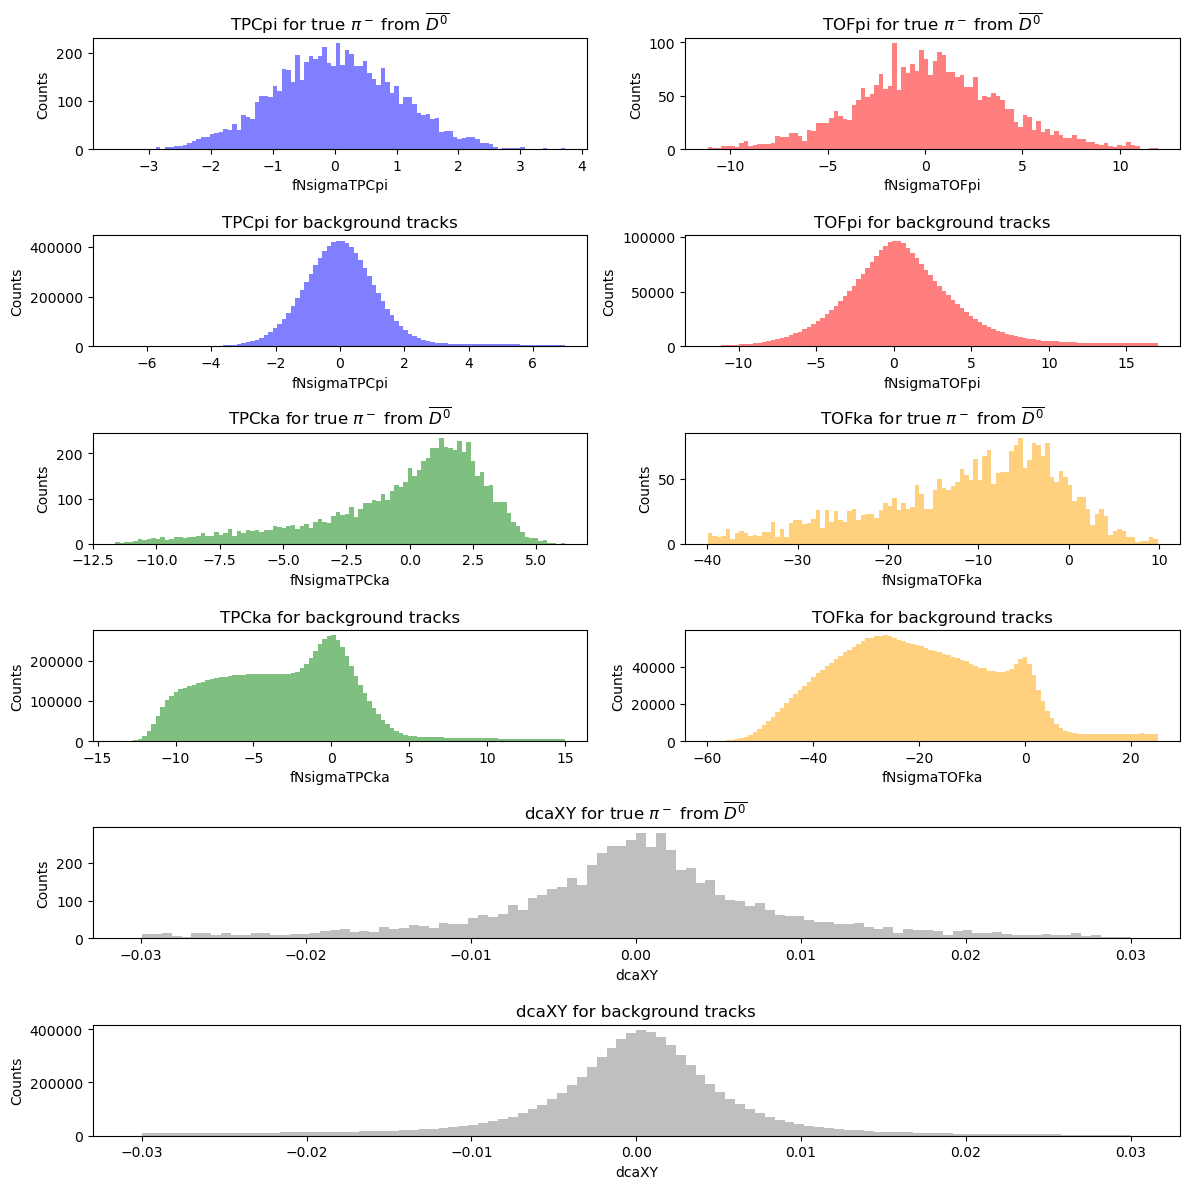

In [11]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi_anti_D0", "tofpi_anti_D0"],
    ["tpcpi_all", "tofpi_all"],
    ["tpcka_anti_D0", "tofka_anti_D0"],
    ["tpcka_all", "tofka_all"],
    ["dcaxy_anti_D0","dcaxy_anti_D0"],
    ["dcaxy_all","dcaxy_all"],
]

fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 12)
)

# ============================================================
# TPCpi for TRUE anti-D0
# ============================================================
data = final_results.loc[mask_true_pi_from_anti_d0, 'fNsigmaTPCpi'].values
axes["tpcpi_anti_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_anti_D0"].set_title(r"TPCpi for true $\pi^-$ from $\overline{D^0}$")
axes["tpcpi_anti_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_anti_D0"].set_ylabel("Counts")

# ============================================================
# TOFpi for TRUE anti-D0
# ============================================================
data = final_results.loc[mask_true_pi_from_anti_d0, 'fNsigmaTOFpi'].values
data = data[(data > -12) & (data < 12)]
axes["tofpi_anti_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_anti_D0"].set_title(r"TOFpi for true $\pi^-$ from $\overline{D^0}$")
axes["tofpi_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_anti_D0"].set_ylabel("Counts")

# ============================================================
# TPCpi for BACKGROUND
# ============================================================
data = final_results.loc[mask_background, 'fNsigmaTPCpi'].values
data = data[(data > -7) & (data < 7)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for background tracks")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# ============================================================
# TOFpi for BACKGROUND
# ============================================================
data = final_results.loc[mask_background, 'fNsigmaTOFpi'].values
data = data[(data > -12) & (data < 17)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for background tracks")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# ============================================================
# TPCka for TRUE anti-D0
# ============================================================
data = final_results.loc[mask_true_pi_from_anti_d0, 'fNsigmaTPCka'].values
axes["tpcka_anti_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_anti_D0"].set_title(r"TPCka for true $\pi^-$ from $\overline{D^0}$")
axes["tpcka_anti_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_anti_D0"].set_ylabel("Counts")

# ============================================================
# TOFka for TRUE anti-D0
# ============================================================
data = final_results.loc[mask_true_pi_from_anti_d0, 'fNsigmaTOFka'].values
data = data[(data > -40) & (data < 12)]
axes["tofka_anti_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_anti_D0"].set_title(r"TOFka for true $\pi^-$ from $\overline{D^0}$")
axes["tofka_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_anti_D0"].set_ylabel("Counts")

# ============================================================
# TPCka for BACKGROUND
# ============================================================
data = final_results.loc[mask_background, 'fNsigmaTPCka'].values
data = data[(data > -20) & (data < 15)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for background tracks")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# ============================================================
# TOFka for BACKGROUND
# ============================================================
data = final_results.loc[mask_background, 'fNsigmaTOFka'].values
data = data[(data > -60) & (data < 25)]
axes["tofka_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for background tracks")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# ============================================================
# DCAxy for TRUE anti-D0
# ============================================================
data = final_results.loc[mask_true_pi_from_anti_d0, 'fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_anti_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_anti_D0"].set_title(r"dcaXY for true $\pi^-$ from $\overline{D^0}$")
axes["dcaxy_anti_D0"].set_xlabel("dcaXY")
axes["dcaxy_anti_D0"].set_ylabel("Counts")

# ============================================================
# DCAxy for BACKGROUND
# ============================================================
data = final_results.loc[mask_background, 'fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for background tracks")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()

del data


### $K^-$ TRACKS
Let's observe the distribution of the variables for the $Kaons^-$ tracks, for both the known $D_0$ and also for all the combinatory background.

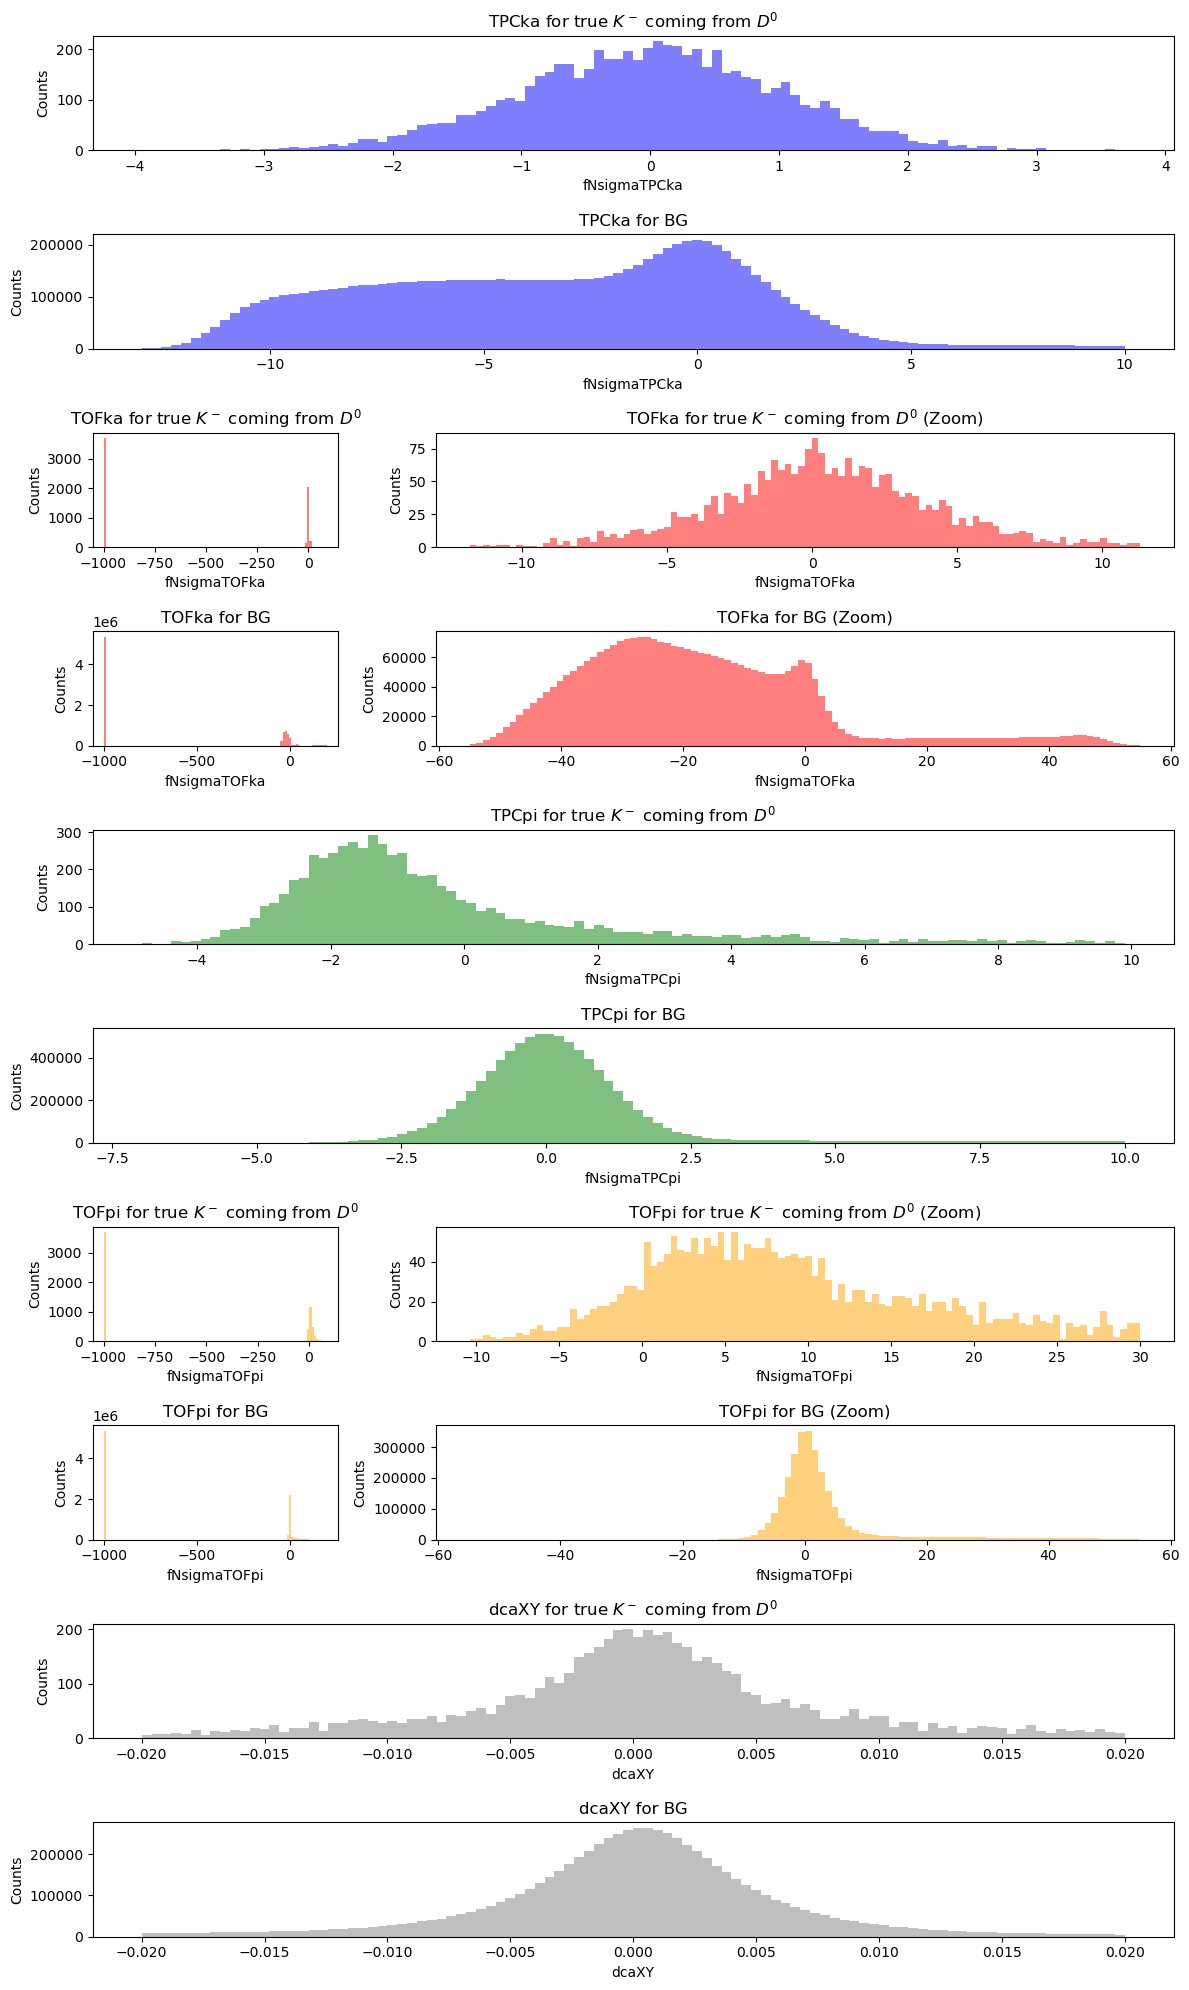

In [12]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka_D0", "tpcka_D0"],
    ["tpcka_all", "tpcka_all"],
    ["tofka_D0", "tofka_zoom_D0"],
    ["tofka_all", "tofka_zoom_all"],
    ["tpcpi_D0", "tpcpi_D0"],
    ["tpcpi_all", "tpcpi_all"],
    ["tofpi_D0", "tofpi_zoom_D0"],
    ["tofpi_all", "tofpi_zoom_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 20),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot TPCka FOR TRUE D0---
data = final_results.loc[mask_true_k_from_d0, 'fNsigmaTPCka'].values
axes["tpcka_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_D0"].set_title(r"TPCka for true $K^-$ coming from $D^0$")
axes["tpcka_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTPCka'].values
data = data[(data > -13) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for BG")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka FOR TRUE D0 ---
data = final_results.loc[mask_true_k_from_d0, 'fNsigmaTOFka'].values
data = data[(data > -1000) & (data < 100)]
axes["tofka_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_D0"].set_title(r"TOFka for true $K^-$ coming from $D^0$")
axes["tofka_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_D0"].set_ylabel("Counts")

# --- Plot TOFka zoom (-12,12) FOR TRUE D0 ---
data_zoom = data[(data > -12) & (data < 12)]
axes["tofka_zoom_D0"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_D0"].set_title(r"TOFka for true $K^-$ coming from $D^0$ (Zoom)")
axes["tofka_zoom_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_D0"].set_ylabel("Counts")

# --- Plot TOFka completo FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTOFka'].values
data = data[(data > -1000) & (data < 200)]
axes["tofka_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for BG")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# --- Plot TOFka zoom FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofka_zoom_all"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_all"].set_title(r"TOFka for BG (Zoom)")
axes["tofka_zoom_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot TPCpi FOR TRUE D0 ---
data = final_results.loc[mask_true_k_from_d0, 'fNsigmaTPCpi'].values
data = data[ data < 10 ]
axes["tpcpi_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_D0"].set_title(r"TPCpi for true $K^-$ coming from $D^0$")
axes["tpcpi_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTPCpi'].values
data = data[(data > -13) & (data < 10)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for BG")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR TRUE D0 ---
data = final_results.loc[mask_true_k_from_d0, 'fNsigmaTOFpi'].values
data = data[(data > -1000) & (data < 100)]
axes["tofpi_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_D0"].set_title(r"TOFpi for true $K^-$ coming from $D^0$")
axes["tofpi_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_D0"].set_ylabel("Counts")

# --- Plot TOFpi zoom (-12,12) FOR TRUE D0 ---
data_zoom = data[(data > -12) & (data < 30)]
axes["tofpi_zoom_D0"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_D0"].set_title(r"TOFpi for true $K^-$ coming from $D^0$ (Zoom)")
axes["tofpi_zoom_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_D0"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTOFpi'].values
data = data[(data > -1000) & (data < 200)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for BG")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot TOFpi zoom FOR BG ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofpi_zoom_all"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_all"].set_title(r"TOFpi for BG (Zoom)")
axes["tofpi_zoom_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_all"].set_ylabel("Counts")
#-------------------------------------------------------------------

# --- Plot dcaXY FOR TRUE D0 ---
data = final_results.loc[mask_true_k_from_d0, 'fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_D0"].set_title(r"dcaXY for true $K^-$ coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY")
axes["dcaxy_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR BG ---
data = final_results.loc[mask_background, 'fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for BG")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()
del data

### $K^+$ TRACKS
Let's observe the distribution of the variables for the $Kaons^+$ tracks, for both the known $anti-D_0$ and also for all the combinatory background.

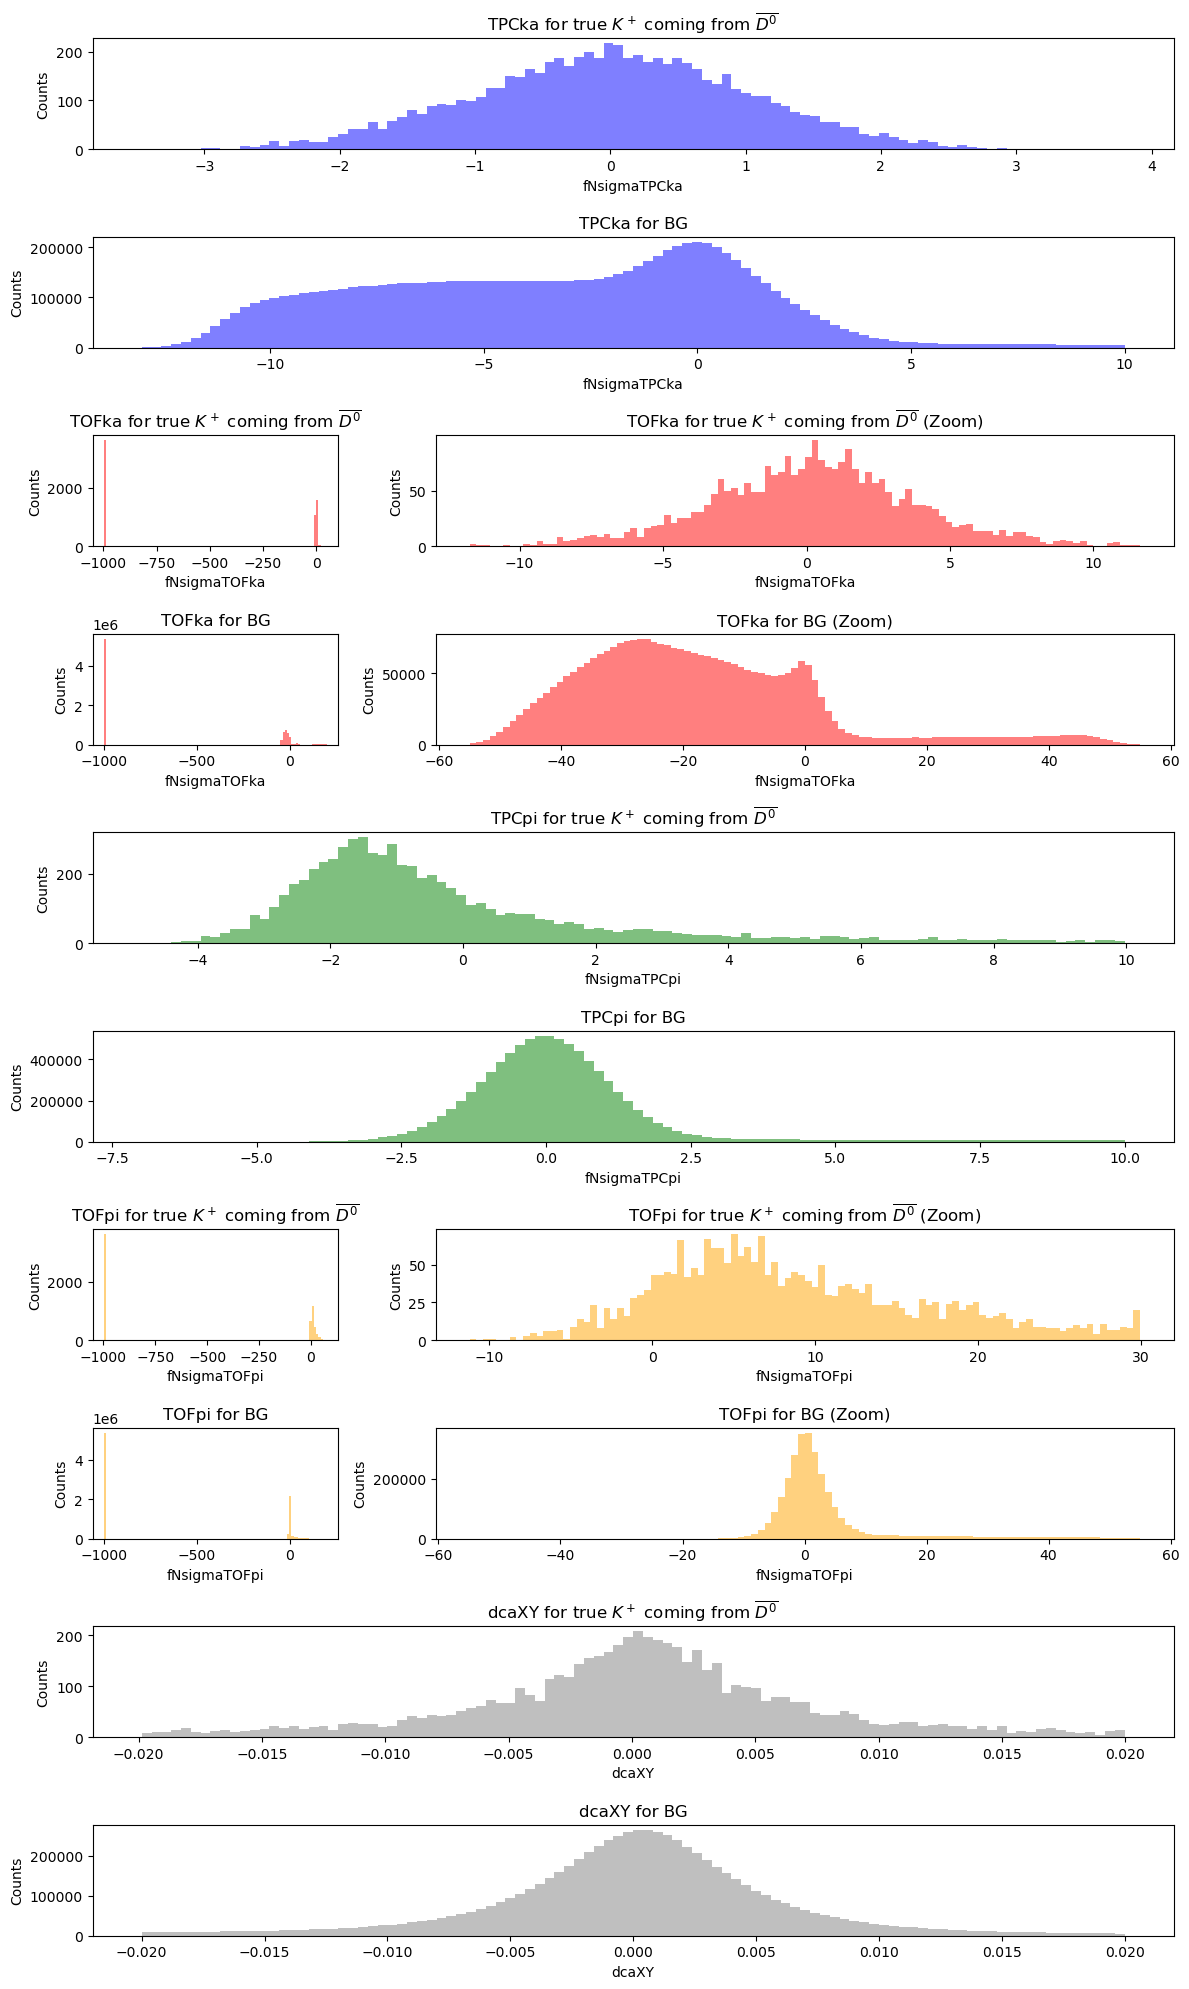

In [13]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka_anti_D0", "tpcka_anti_D0"],
    ["tpcka_all", "tpcka_all"],
    ["tofka_anti_D0", "tofka_zoom_anti_D0"],
    ["tofka_all", "tofka_zoom_all"],
    ["tpcpi_anti_D0", "tpcpi_anti_D0"],
    ["tpcpi_all", "tpcpi_all"],
    ["tofpi_anti_D0", "tofpi_zoom_anti_D0"],
    ["tofpi_all", "tofpi_zoom_all"],
    ["dcaxy_anti_D0","dcaxy_anti_D0"],
    ["dcaxy_all","dcaxy_all"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 20),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot TPCka FOR TRUE anti_D0---
data = final_results.loc[mask_true_k_from_anti_d0, 'fNsigmaTPCka'].values
axes["tpcka_anti_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_anti_D0"].set_title(r"TPCka for true $K^+$ coming from $\overline{D^0}$")
axes["tpcka_anti_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_anti_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTPCka'].values
data = data[(data > -13) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for BG")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka completo FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_k_from_anti_d0, 'fNsigmaTOFka'].values
data = data[(data > -1000) & (data < 100)]
axes["tofka_anti_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_anti_D0"].set_title(r"TOFka for true $K^+$ coming from $\overline{D^0}$")
axes["tofka_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka zoom (-12,12) FOR TRUE anti_D0 ---
data_zoom = data[(data > -12) & (data < 12)]
axes["tofka_zoom_anti_D0"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_anti_D0"].set_title(r"TOFka for true $K^+$ coming from $\overline{D^0}$ (Zoom)")
axes["tofka_zoom_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka completo FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTOFka'].values
data = data[(data > -1000) & (data < 200)]
axes["tofka_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for BG")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# --- Plot TOFka zoom FOR BG ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofka_zoom_all"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_all"].set_title(r"TOFka for BG (Zoom)")
axes["tofka_zoom_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_all"].set_ylabel("Counts")
#-------------------------------------------------------------------

# --- Plot TPCpi FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_k_from_anti_d0, 'fNsigmaTPCpi'].values
data = data[ data < 10 ]
axes["tpcpi_anti_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_anti_D0"].set_title(r"TPCpi for true $K^+$ coming from $\overline{D^0}$")
axes["tpcpi_anti_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_anti_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTPCpi'].values
data = data[(data > -13) & (data < 10)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for BG")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_k_from_anti_d0, 'fNsigmaTOFpi'].values
data = data[(data > -1000) & (data < 100)]
axes["tofpi_anti_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_anti_D0"].set_title(r"TOFpi for true $K^+$ coming from $\overline{D^0}$")
axes["tofpi_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_anti_D0"].set_ylabel("Counts")

# --- Plot TOFpi zoom (-12,12) FOR TRUE anti_D0 ---
data_zoom = data[(data > -12) & (data < 30)]
axes["tofpi_zoom_anti_D0"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_anti_D0"].set_title(r"TOFpi for true $K^+$ coming from $\overline{D^0}$ (Zoom)")
axes["tofpi_zoom_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_anti_D0"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTOFpi'].values
data = data[(data > -1000) & (data < 200)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for BG")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot TOFpi zoom FOR BG ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofpi_zoom_all"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_all"].set_title(r"TOFpi for BG (Zoom)")
axes["tofpi_zoom_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot dcaXY FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_k_from_anti_d0, 'fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_anti_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_anti_D0"].set_title(r"dcaXY for true $K^+$ coming from $\overline{D^0}$")
axes["dcaxy_anti_D0"].set_xlabel("dcaXY")
axes["dcaxy_anti_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR BG ---
data = final_results.loc[mask_background, 'fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for BG")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()
del data

We can see that the variables TPCka and TOFka can be very useful as cuts. 

But what to do with data at -999 TOF? Let's see.

In [30]:
print(f"Total number of D0s:        {d0_tot:.0f}")
print(f"Total number of D0s tracks: {d0_tot*2:.0f}")
data = final_results.loc[ mask_true_d0, 'fNsigmaTOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of True D0s tracks with TOFka = -999:       {len(data)/(d0_tot*2):.2f}")
print(f"Fraction of True D0s tracks with TOFka != -999: :    { ( (d0_tot*2)-len(data)) / (d0_tot*2) :.2f} \n")

print(f"Total number of antiD0s:        {anti_d0_tot:.0f}")
print(f"Total number of antiD0s tracks: {anti_d0_tot*2:.0f}")
data = final_results.loc[ mask_true_anti_d0, 'fNsigmaTOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of True anti_D0s tracks with TOFka = -999:  {len(data)/(anti_d0_tot*2):.2f}")
print(f"Fraction of True anti_D0s tracks with TOFka != -999: { ((anti_d0_tot*2)-len(data)) / (anti_d0_tot*2) :.2f} \n")

print(f"Total number of tracks data: {len(final_results):_}")
data = final_results['fNsigmaTOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of all tracks data with TOFka = -999:  :    {len(data)/len(final_results) :.2f}")
print(f"Fraction of all tracks data with TOFka != -999: :    { (len(final_results)-len(data)) / len(final_results) :.2f}")
del data

Total number of D0s:        6522
Total number of D0s tracks: 13044
Fraction of True D0s tracks with TOFka = -999:       0.52
Fraction of True D0s tracks with TOFka != -999: :    0.48 

Total number of antiD0s:        6779
Total number of antiD0s tracks: 13558
Fraction of True anti_D0s tracks with TOFka = -999:  0.50
Fraction of True anti_D0s tracks with TOFka != -999: 0.50 

Total number of tracks data: 8_877_719
Fraction of all tracks data with TOFka = -999:  :    0.61
Fraction of all tracks data with TOFka != -999: :    0.39


This is the thing: as we saw in the plots, TOF is the better chance we have at identifying the $D_0$. And if we keep the data with TOFka=-999, we keep a lot of background. In particulare we keep a lot of back ground and some signal difficult to identify (cause we can't use TOF).   
Instead if we remove it, yeah we lose 44% of true D0, but we stay in a zone where our cuts are very effective (see plot above). So cutting away TOFka=-999 could be a good choice.

### FOCUS ON $dca_{XY}$ per $p_T$ of the single tracks
Let's focus on the distribution of $dca_{XY}$ variable in various $p_T$ distributions.

In [32]:
multiple_masks_pt_single_track = [ 
    ( final_results["fPt"].between(0,1) ), 
    ( final_results["fPt"].between(1,2) ), 
    ( final_results["fPt"].between(2,3) ),
    ( final_results["fPt"].between(3,4) ), 
    ( final_results["fPt"].between(4,5) ), 
    ( final_results["fPt"].between(5,6) ) ]
pt_windows_single_track = [ "0-1", "1-2", "2-3", "3-4", "4-5", "5-6"]

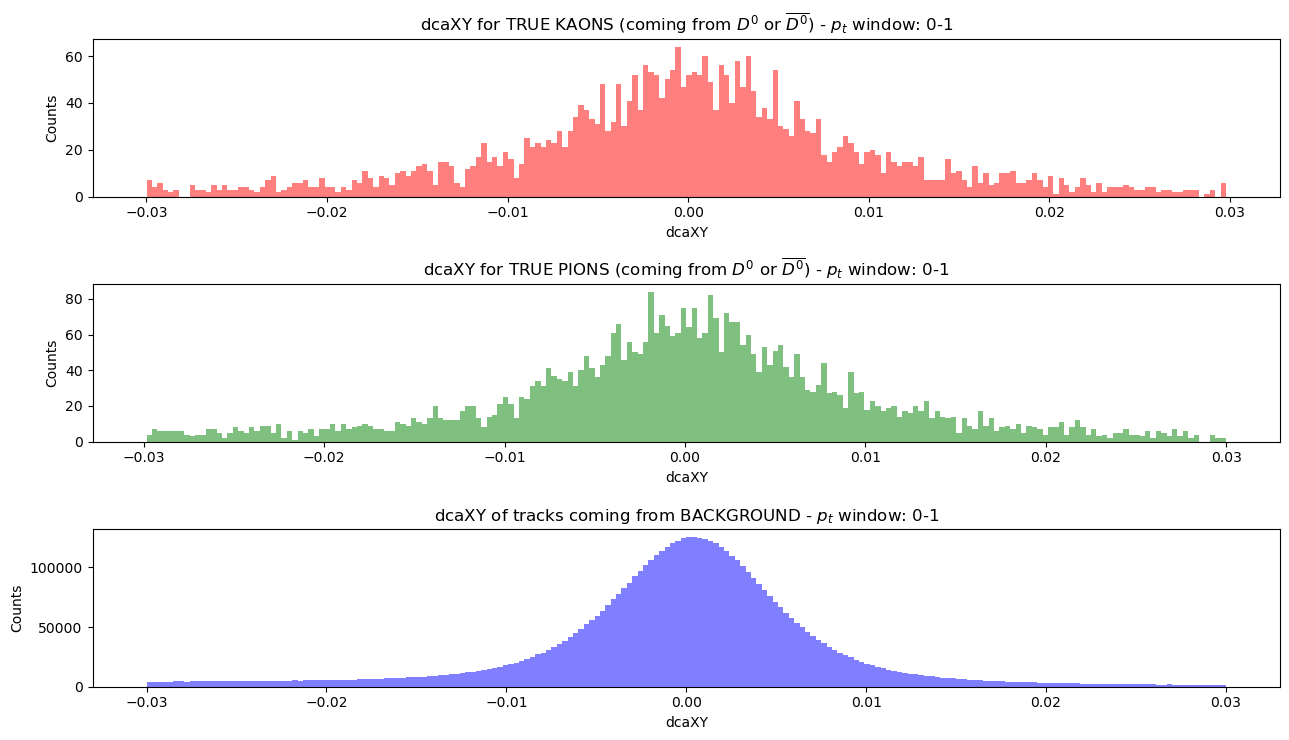

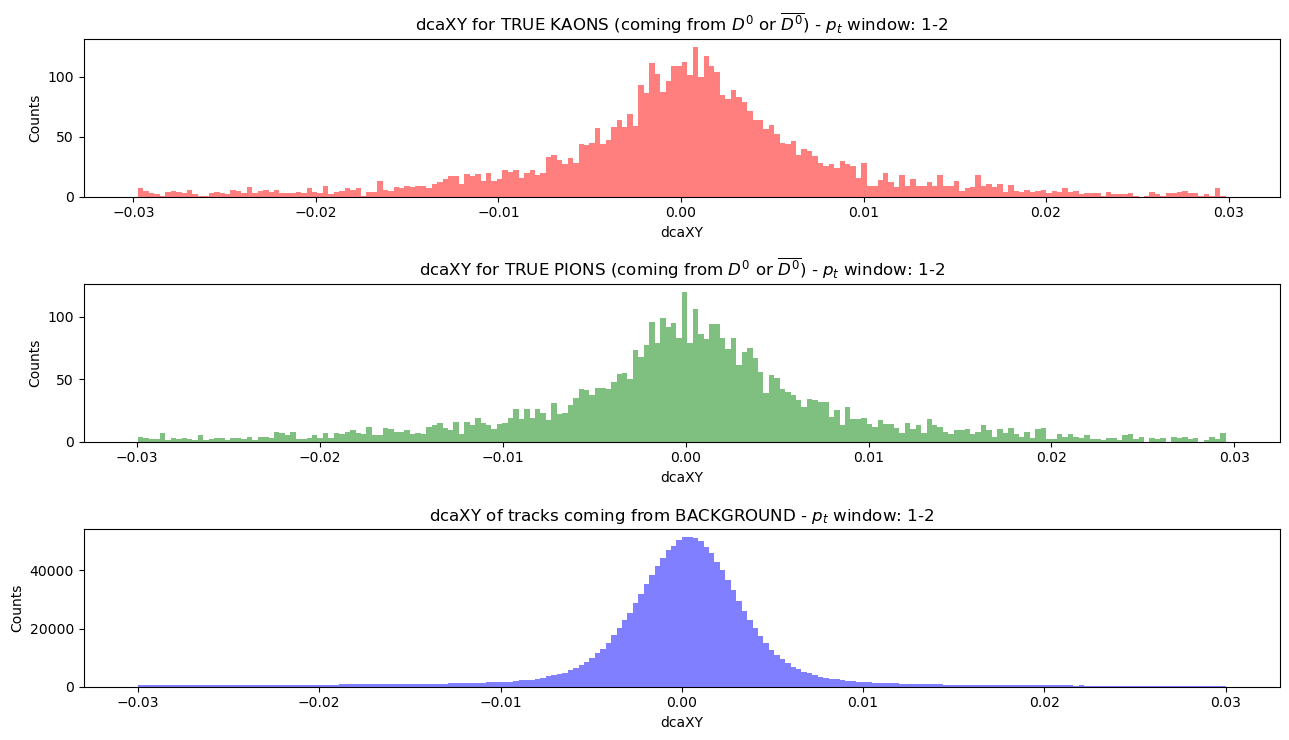

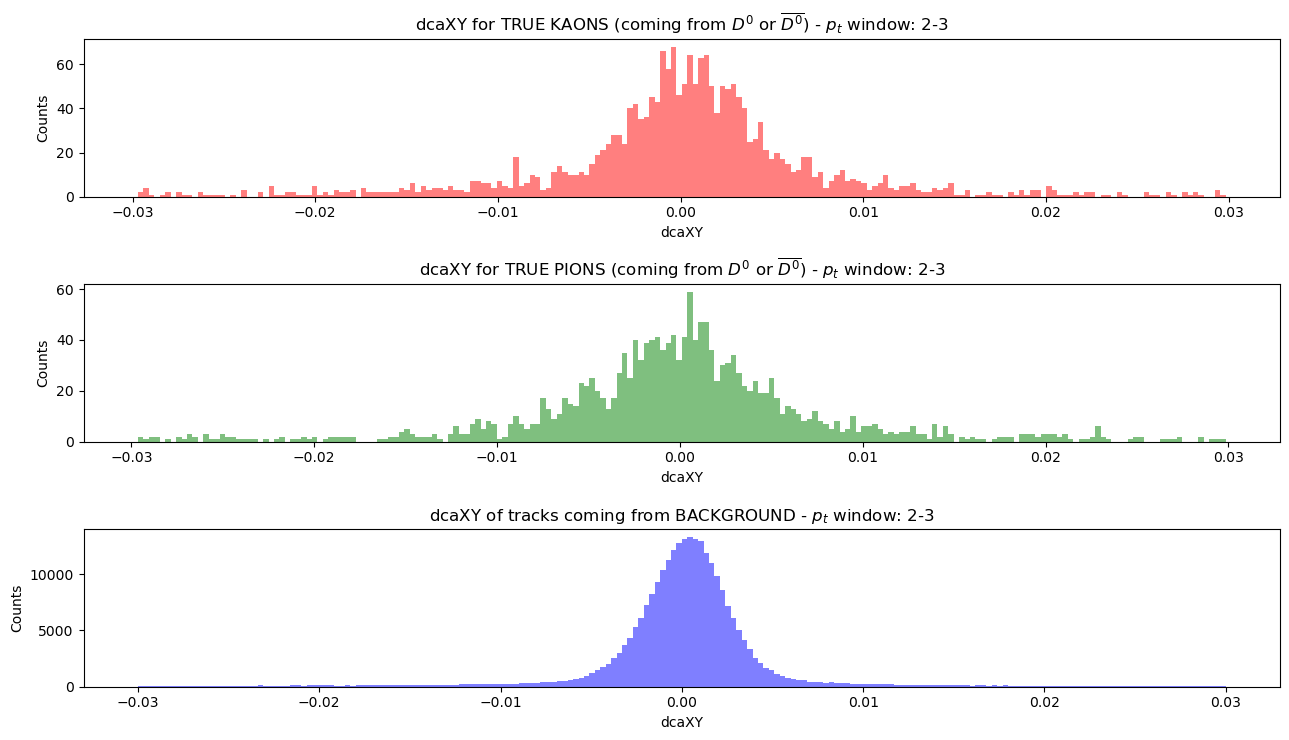

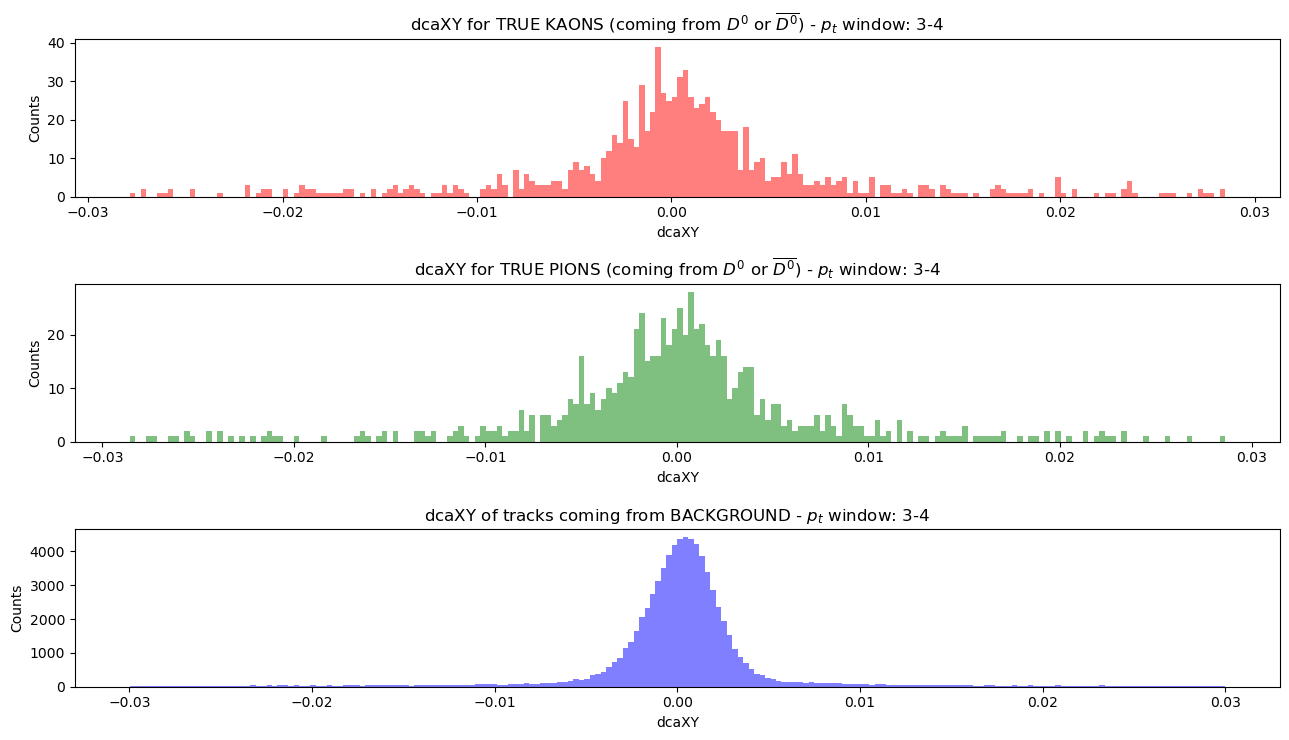

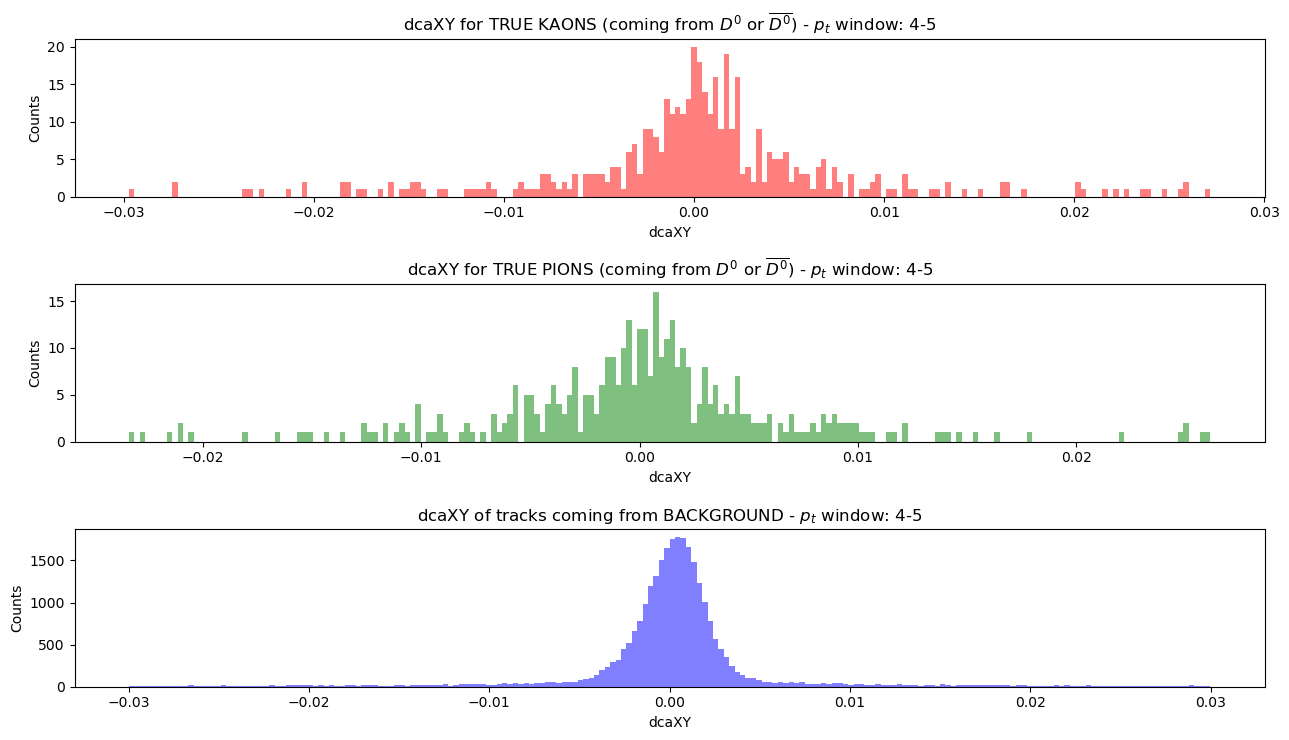

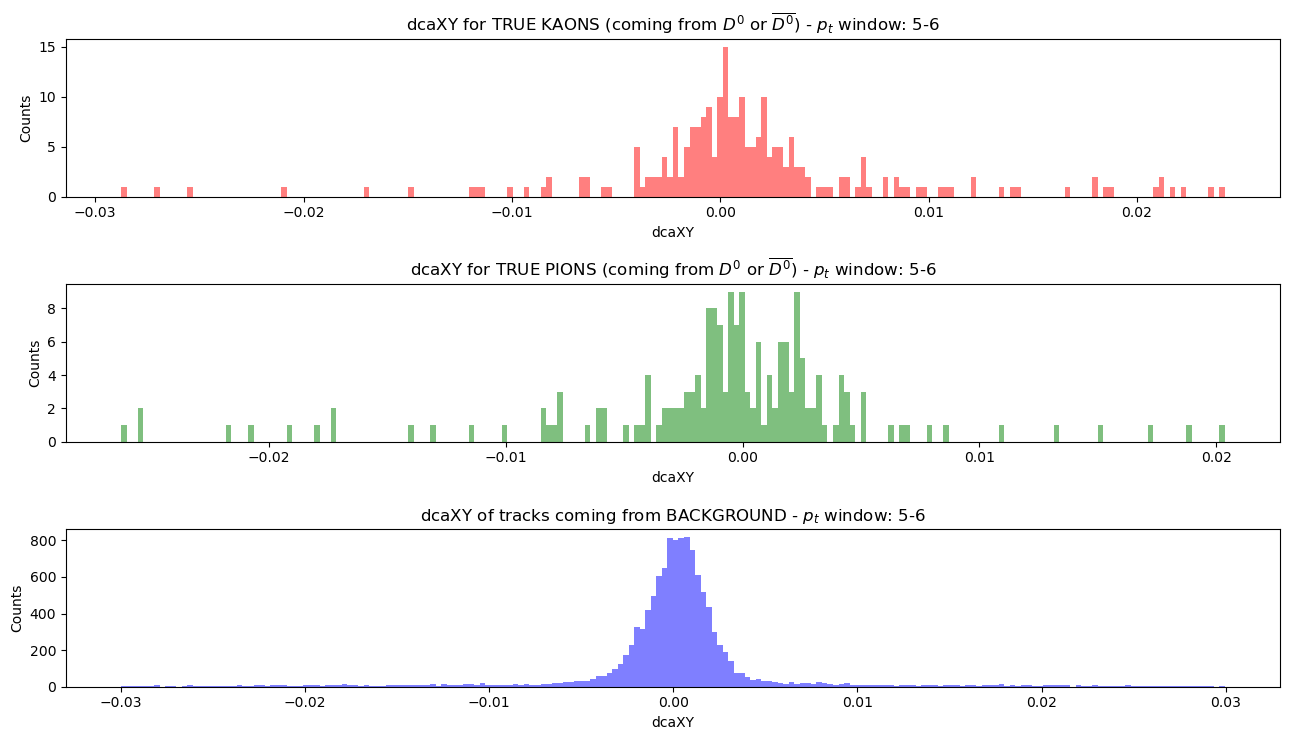

In [33]:
N_BINS = 200

for i, mask_name in enumerate(pt_windows_single_track):
    num_of_plots = 3
    fig, axs = plt.subplots(num_of_plots, 1, figsize=(13, 2.5 * num_of_plots))
    
    #-------------------------------------------------------------------
    # --- Plot dcaXY for k TRUE SIGNAL ---
    data = final_results.loc[ mask_true_k & multiple_masks_pt_single_track[i], 'fDcaXY'].values
    data = data[(data > -0.03) & (data < 0.03)]
    axs[0].hist(data, bins=N_BINS, color="red", alpha=0.5)
    axs[0].set_title(r"dcaXY for TRUE KAONS (coming from $D^0$ or $\overline{D^0}$) - $p_t$ window: " + str(mask_name))
    axs[0].set_xlabel("dcaXY")
    axs[0].set_ylabel("Counts")

    #-------------------------------------------------------------------
    # --- Plot dcaXY for pi TRUE SIGNAL ---
    data = final_results.loc[ mask_true_pi & multiple_masks_pt_single_track[i], 'fDcaXY'].values
    data = data[(data > -0.03) & (data < 0.03)]
    axs[1].hist(data, bins=N_BINS, color="green", alpha=0.5)
    axs[1].set_title(r"dcaXY for TRUE PIONS (coming from $D^0$ or $\overline{D^0}$) - $p_t$ window: " + str(mask_name))
    axs[1].set_xlabel("dcaXY")
    axs[1].set_ylabel("Counts")
    
    #-------------------------------------------------------------------
    # --- Plot dcaXY for BACKGROUND ---
    data = final_results.loc[ mask_background & multiple_masks_pt_single_track[i], 'fDcaXY'].values
    data = data[(data > -0.03) & (data < 0.03)]
    axs[2].hist(data, bins=N_BINS, color="blue", alpha=0.5)
    axs[2].set_title(r"dcaXY of tracks coming from BACKGROUND - $p_t$ window: " + str(mask_name))
    axs[2].set_xlabel("dcaXY")
    axs[2].set_ylabel("Counts")
    
    plt.tight_layout()
    plt.show()
    
    del data

## SEARCH FOR A CUT IN $dcaXY$

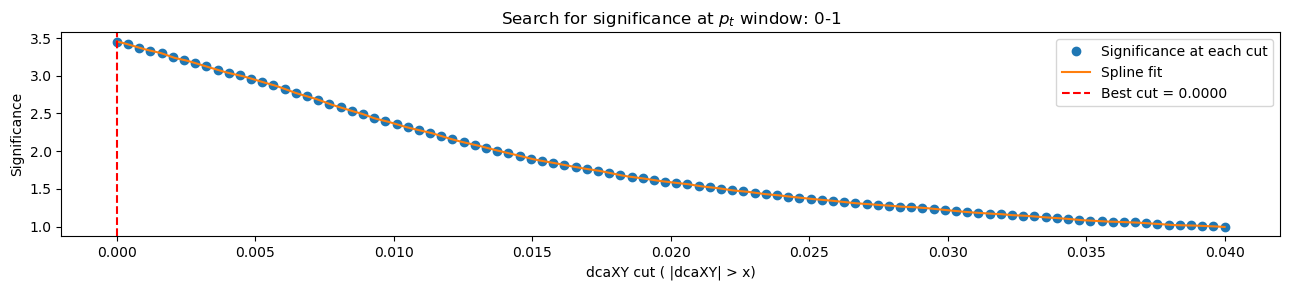

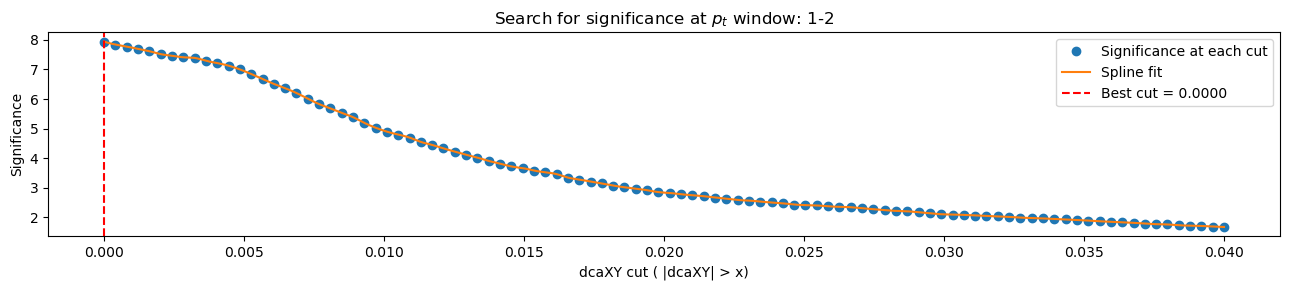

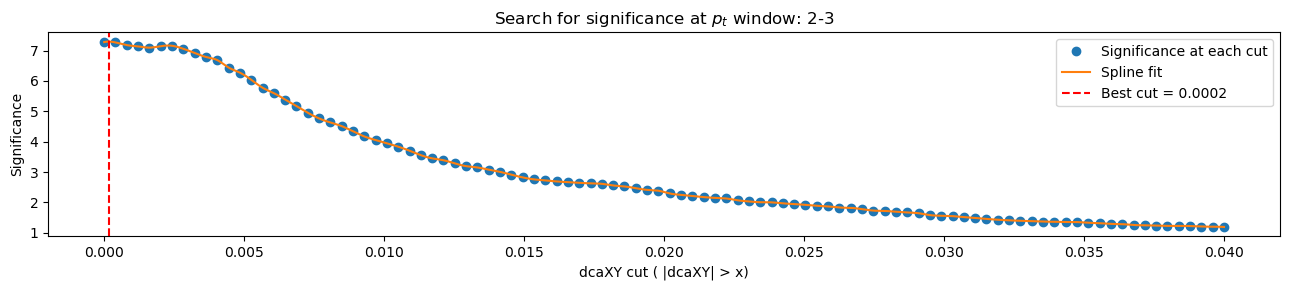

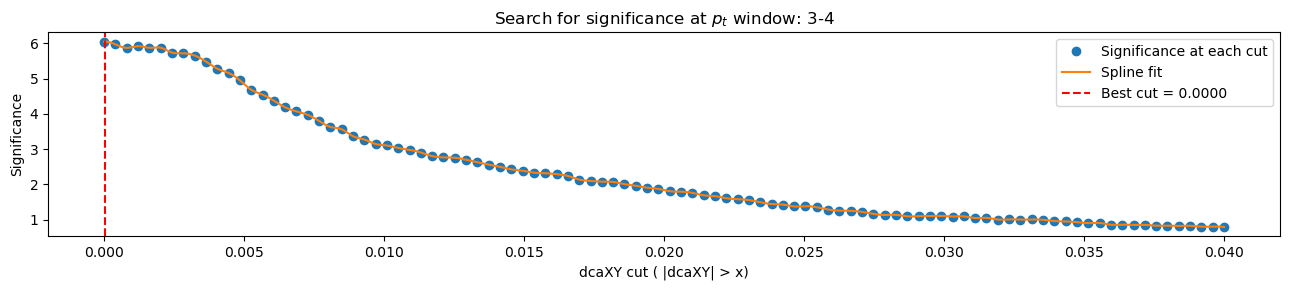

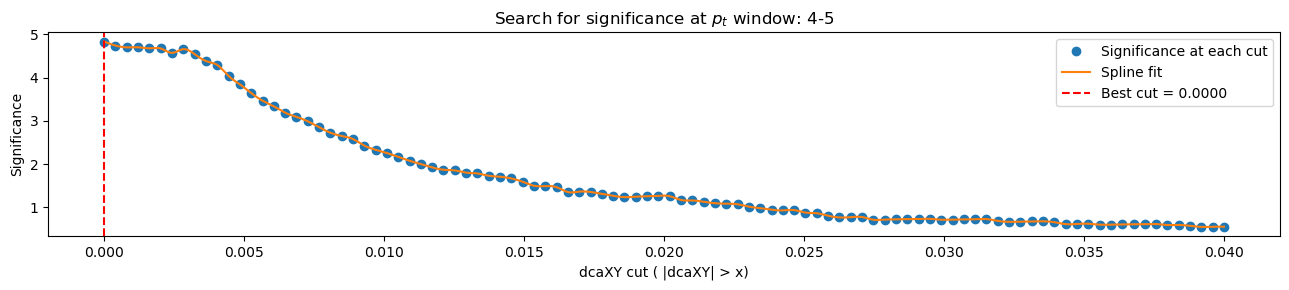

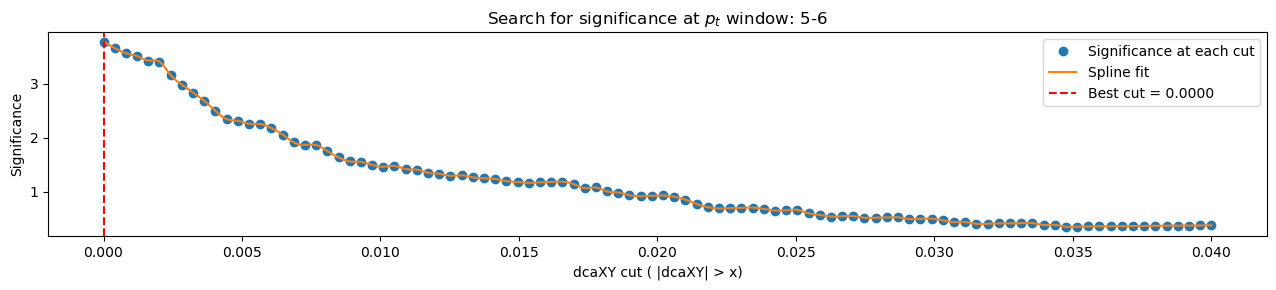

In [34]:
for i, mask_name in enumerate(pt_windows_single_track): 

    # initialization
    x_val = np.linspace( 0 , 0.04, 100)   # meaningful values for x axis
    y_val =[]       # this will save the significance value for each cut
    
    signal_df = final_results.loc[ mask_signal & multiple_masks_pt_single_track[i], 'fDcaXY'].values
    background_df = final_results.loc[ mask_background & multiple_masks_pt_single_track[i], 'fDcaXY'].values

    # compute significance for |dcaXY| > x
    for x in x_val:
        numerator = np.sum(np.abs(signal_df) > x)
        denominator = np.sum(np.abs(background_df) > x)
        total = numerator + denominator

        y_val.append(0 if total == 0 else numerator / np.sqrt(total))
    
    # INTERPOLATION with spline:
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)                  # drawing the spline
    best_cut = x_dense[np.argmax(y_dense)]     # saving the cut that gives highest significance
    
    # PLOT:
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val, 'o', label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.set_title('Search for significance at $p_t$ window: ' + str(mask_name))
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.4f}')
    ax.set_xlabel('dcaXY cut ( |dcaXY| > x)')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()


It doesn't seem to be useful.

## SEARCH FOR BEST CUTS in TOF and TPC
Let's search (manually for now) for best cuts over the variables ['neg_TOFka', 'neg_TPCka', 'pos_TOFka', 'pos_TPCka'], appeared to be the best choices from previous plots.

Migliori cuts trovati all'ultima run (da verificare):
```
Best cuts found:
neg_TOFka: ±7.25
neg_TPCka: ±1.97
pos_TOFka: ±7.83
pos_TPCka: ±1.83
Maximum significance S/√(S+B): 5.301
```

In [41]:
# Decide if we want to run the search
search = "yes"

# --- DATA ---
signal_data = final_results.loc[mask_signal, ['fNsigmaTOFka', 'fNsigmaTPCka']]
background_data = final_results.loc[mask_background, ['fNsigmaTOFka', 'fNsigmaTPCka']]

# --- DEFINE CANDIDATE CUTS ---
TOF_cuts = np.linspace(2, 10, 20)    # thresholds for TOF
TPC_cuts = np.linspace(2, 7, 20)  # thresholds for TPC

# --- INITIALIZATION ---
total_iterations = len(TOF_cuts) * len(TPC_cuts)
iteration = 0
best_significance = 0
best_cuts = {}
significance_matrix = np.zeros((len(TOF_cuts), len(TPC_cuts)))  # store significance

# --- GRID SEARCH ---
if search == "yes":
    for i, tof_cut in enumerate(TOF_cuts):
        for j, tpc_cut in enumerate(TPC_cuts):

            iteration += 1
            if iteration % 50 == 0 or iteration == 1:
                print(f"{iteration}/{total_iterations}", end=' ')

            # Define rectangular PID cut
            signal_pass = (
                (signal_data['fNsigmaTOFka'].between(-tof_cut, tof_cut)) &
                (signal_data['fNsigmaTPCka'].between(-tpc_cut, tpc_cut))
            )
            background_pass = (
                (background_data['fNsigmaTOFka'].between(-tof_cut, tof_cut)) &
                (background_data['fNsigmaTPCka'].between(-tpc_cut, tpc_cut))
            )

            s = signal_pass.sum()
            b = background_pass.sum()

            if s + b > 0:
                significance = s / np.sqrt(s + b)
            else:
                significance = 0

            significance_matrix[i, j] = significance

            if significance > best_significance:
                best_significance = significance
                best_cuts = {'TOFka_cut': tof_cut, 'TPCka_cut': tpc_cut}

# --- RESULTS ---
if search == "yes":
    print('\nBest cuts found:')
    for k, v in best_cuts.items():
        print(f"{k}: ±{v:.2f}")
    print(f"Maximum significance S/√(S+B): {best_significance:.3f}")

1/400 50/400 100/400 150/400 200/400 250/400 300/400 350/400 400/400 
Best cuts found:
TOFka_cut: ±7.89
TPCka_cut: ±6.47
Maximum significance S/√(S+B): 9.754


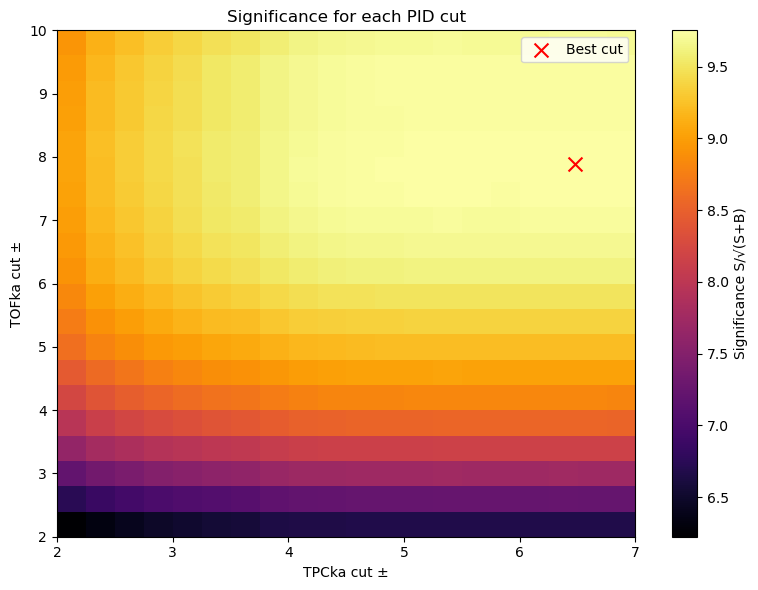

In [62]:
# --- PLOT HEATMAP ---
plt.figure(figsize=(8,6))
plt.imshow(significance_matrix, origin='lower', 
           extent=[TPC_cuts[0], TPC_cuts[-1], TOF_cuts[0], TOF_cuts[-1]],
           aspect='auto', cmap='inferno')
plt.colorbar(label='Significance S/√(S+B)')
plt.scatter(best_cuts['TPCka_cut'], best_cuts['TOFka_cut'], color='red', marker='x', s=100, label='Best cut')
plt.xlabel('TPCka cut ±')
plt.ylabel('TOFka cut ±')
plt.title('Significance for each PID cut')
plt.legend()
plt.tight_layout()
plt.show()

---

---

---